# <center> Предсказание рейтинга отеля

## Постановка задачи

Я буду работать с датасетом, в котором содержатся сведения о 515 000 отзывов на отели Европы. Модель, которую я буду обучать, должна предсказывать рейтинг отеля по данным сайта Booking на основе имеющихся в датасете данных

**Главная задача**: Добиться максимальной точности модели, с помощью более тщательной подготовки данных

`reviewer_score` (*рейтинг отелей*) - целевая переменная, на основе которой мы будем делать предсказание 

## Загрузка данных

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
import statsmodels.stats as sm

import category_encoders as ce

from sklearn import preprocessing

In [2]:
hotels = pd.read_csv('data/hotels_train.csv')
hotels.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


## Очистка данных

Очистка от дубликатов

In [3]:
print("Количество строк в прошлом датасете: ", hotels.shape[0])
hotels = hotels.drop_duplicates()
print("Количество строк в новом датасете: ", hotels.shape[0])

Количество строк в прошлом датасете:  386803
Количество строк в новом датасете:  386496


Проверим целевую переменную на наличие аномальных значений

In [4]:
print(hotels[(hotels['reviewer_score'] < 0) | (hotels['reviewer_score'] > 10)].shape[0])
print('Аномальных значение не обнаружено')

0
Аномальных значение не обнаружено


In [5]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386496 non-null  object 
 1   additional_number_of_scoring                386496 non-null  int64  
 2   review_date                                 386496 non-null  object 
 3   average_score                               386496 non-null  float64
 4   hotel_name                                  386496 non-null  object 
 5   reviewer_nationality                        386496 non-null  object 
 6   negative_review                             386496 non-null  object 
 7   review_total_negative_word_counts           386496 non-null  int64  
 8   total_number_of_reviews                     386496 non-null  int64  
 9   positive_review                             386496 non-null  object 
 10  r

Имеются пропущенные значения в столбцах `lat` и `lng`

In [6]:
pass_hotels = hotels.isnull().mean() * 100
if (pass_hotels['lat'] < 30 or pass_hotels['lng'] < 30):
    print('В переменных меньше 30% пропусков. Не будем удалять столбцы')
else: print('В переменных более 30% пропусков. Будем удалять столбцы')

В переменных меньше 30% пропусков. Не будем удалять столбцы


Заполним недостающие значения константами

In [7]:
fillna_values = {
    'lat': hotels['lat'].mean(),
    'lng': hotels['lng'].mean()
}
hotels = hotels.fillna(fillna_values)

## Исследование данных

Уровень значимости $\alpha=0.05$

In [8]:
alpha = 0.05

In [9]:
# Функция для принятия решения об отклонении нулевой гипотезы
def test_hypothesis(p):
    if p<=alpha:
        print(f'pvalue {round(p, 3)} меньше чем уровень значимости {alpha}, отклоняем нулевую гипотезу в пользу альтернативной')
    else:
        print(f'pvalue {round(p, 3)} больше чем уровень значимости {alpha}. Нет оснований отвергнуть нулевую гипотезу')
        
# Функция для принятия решения о нормальности
def test_normal(p):
    if p<=alpha:
        print(f'pvalue {round(p, 3)} меньше чем уровень значимости {alpha}. Распределение не нормальное')
        return 0
    else:
        print(f'pvalue {round(p, 3)} больше чем уровень значимости {alpha}. Распределение нормальное')
        return 1
        
# Функция для принятия решения о равности дисперсий
def test_variance(p):
    if p<=alpha:
        print(f'pvalue {round(p, 3)} меньше чем уровень значимости {alpha}. Дисперсии неравны')
    else:
        print(f'pvalue {round(p, 3)} больше чем уровень значимости {alpha}. Нет оснований отвергнуть нулевую гипотезу, дисперсии равны')

#### Как соотносятся оценки рецензетов из разных стран?

**Сформулируем нулевые и альтернативные гипотезы**

*Нулевая гипотеза $(H_0)$*: Страна рецензента не влияет на его оценку
$$H_0 : h_1 = h_2 = h_3 = ... $$

*Альтернативная гипотеза $(H_1)$*: Страна рецензента влияет на его оценку
$$H_0 : h_1 \neq h_2 \neq h_3 \neq ...$$

**Проверка на нормальность**

In [10]:
reviewers_country = []

unique_countries = list(hotels['reviewer_nationality'].unique())

for country in unique_countries:
    reviewers_country.append(hotels[hotels['reviewer_nationality'] == country]['reviewer_score'])
    
for i in reviewers_country:
    if (test_normal(stats.shapiro(i)[1])) == 0: 
        print('Есть ненормальные распределения в группах')
        break

pvalue 0.0 меньше чем уровень значимости 0.05. Распределение не нормальное
Есть ненормальные распределения в группах


c:\Users\Aorus\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 183952.
  res = hypotest_fun_out(*samples, **kwds)


- Какой тип признака у оценки рецензента? - **Количественный**
- Сколько сравнимаемых групп? - **Очень много**
- Группы зависимые или независимые? - **Независимые**
- Распределение? - **Есть ненормальные**

Подходящий тест: **Критерий Краскела — Уоллиса** (так как хотя бы в одной группе распределение ненормальное)

In [11]:
test_hypothesis(stats.kruskal(*reviewers_country)[1])
print('Страна рецензента влияет на его оценку')

pvalue 0.0 меньше чем уровень значимости 0.05, отклоняем нулевую гипотезу в пользу альтернативной
Страна рецензента влияет на его оценку


**Вывод** 

Мы можем точно сказаать, что оценка рецензента зависит от его страны

#### Увеличивается ли оценка рецензента от уменьшения количества слов в отрицательном отзыве?

**Сформулируем нулевые и альтернативные гипотезы**

*Нулевая гипотеза $(H_0)$*: У группы с меньшим количеством слов в отрицательном отзыве меньше(или одинакова) оценка, чем у группы с большим количеством слов в отрицательном отзыве
$$H_0 : h_1 <= h_2 $$

*Альтернативная гипотеза $(H_1)$*: У группы с меньшим количеством слов в отрицательном отзыве больше оценка, чем у группы с большим количеством слов в отрицательном отзыве
$$H_0 : h_1  > h_2 $$

**Проверка на нормальность**

In [12]:
reviewers_score_negatives_words_less = hotels[hotels['review_total_negative_word_counts'] <= 19]['reviewer_score']
reviewers_score_negatives_words_more = hotels[hotels['review_total_negative_word_counts'] > 19]['reviewer_score']

test_normal(stats.shapiro(reviewers_score_negatives_words_less)[1])
test_normal(stats.shapiro(reviewers_score_negatives_words_more)[1])

pvalue 0.0 меньше чем уровень значимости 0.05. Распределение не нормальное
pvalue 0.0 меньше чем уровень значимости 0.05. Распределение не нормальное


c:\Users\Aorus\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 271079.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Aorus\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 115417.
  res = hypotest_fun_out(*samples, **kwds)


0

**Выбор подходящего теста**
- Какой тип признака у оценки рецензента? - **Количественный**
- Сколько сравнимаемых групп? - **2**
- Группы зависимые или независимые? - **Независимые**
- Распределение? - **Ненормальные**

Подходящий тест: **U-критерий Манна-Уитни**

In [13]:
test_hypothesis(stats.mannwhitneyu(reviewers_score_negatives_words_less, reviewers_score_negatives_words_more, alternative='greater')[1])

pvalue 0.0 меньше чем уровень значимости 0.05, отклоняем нулевую гипотезу в пользу альтернативной


**Вывод** 

Мы можем точно сказать, что чем меньше отрицательных слов в отзыве, тем больше оценка рецензента

## Генерация признаков

Представим признак количества дней между датой проверки и датой очистки в числовом виде

In [14]:
def fetch_days(s):
    result = ''
    for i in s:
        if i.isdigit(): result+=i
    return result
        
hotels['days_since_review'] = hotels['days_since_review'].apply(fetch_days).astype(int)


Создадим признаки года, месяца и дня, когда пользователь оставил отзыв

In [15]:
hotels['review_date_year'] = pd.to_datetime(hotels['review_date']).dt.year

hotels['review_date_month'] = pd.to_datetime(hotels['review_date']).dt.month

hotels['review_date_day'] = pd.to_datetime(hotels['review_date']).dt.day

hotels['review_date_day_of_week'] = pd.to_datetime(hotels['review_date']).dt.day_of_week

Признак комнаты по категории

In [16]:
cat_room = ['standard', 'superior', 'deluxe', 'presidential suite','president', 'royal suite', 'junior suite', 'suite', 'apartment', 'family']

def get_count_people(data):
    data = data.translate({ord(j): "" for j in "[]'"}).lower().split(',')
    for j in data:
        for p in cat_room:
            if p in j:
                return p
    return "standard"

hotels['cat_room'] = hotels['tags'].apply(get_count_people)

Признак на сколько людей рассчитана комната

In [17]:
people = ['triple', 'double', 'single', 'quadruple', 'couple', 'twin', 'solo']

def get_count_people(data):
    data = data.translate({ord(j): "" for j in "[]'"}).lower().split(',')
    for j in data:
        for p in people:
            if p in j:
                if ( p == 'solo' ): p = 'single'
                if ( p == 'couple' or p == 'twin'): p = 'double'
                if ( p == 'family with young children' or p == 'group' or p == 'family with older children' or p == 'travelers with friends'): p = 'quadruple'
                
                return p
    return "is_none"

hotels['type_of_placement'] = hotels['tags'].apply(get_count_people)

In [18]:
hotels['type_of_placement'].value_counts()

type_of_placement
double       259651
single        83200
is_none       35618
triple         6692
quadruple      1335
Name: count, dtype: int64

Признак "Тип поездки"

In [19]:
def type_trip(data):
    data = data.translate({ord(j): "" for j in "[]'"}).split(',')
    for j in data:
        j = j.strip()
        if 'trip' in j: return j
    return 'Leisure trip'

hotels['trip'] = hotels['tags'].apply(type_trip)

Признак количества ночей, в которых пользователь оставался в отеле

In [20]:
def stayed_nights(data):
    data = data.translate({ord(j): "" for j in "[]'"}).split(',')
    for j in data:
        j = j.strip()
        if 'night' in j and 'Stayed' in j:
            return j[7:9].strip()
    return 0

hotels['stayed_nights'] = hotels['tags'].apply(stayed_nights)

Создание признака страны, в которой находится отель

In [21]:
countries = ['United Kingdom', 'Spain', 'France', 'Netherlands', 'Austria', 'Italy']
    
# Создаём колонку со страной отеля
def get_country(a):
    for c in countries:
        if c in a: return c
    
hotels['country_hotel'] = hotels['hotel_address'].apply(get_country)

Создание признаков наличия самых "негативных слов" в отзывах

In [22]:
need_bad_words = ['old', 'dirty', 'bad', 'rude', 'uncomfortable', 'terrible', 'unfriendly']

for i in need_bad_words:
    def get_bad_words(data):
        data = data.lower()
        if i in data: return 1
        return 0
    hotels['revier_negative_'+i] =  hotels['negative_review'].apply(get_bad_words)

Создание признаков наличия самых "положительных слов" в отзывах

In [23]:
need_good_words = ['friendly', 'good', 'helpful', 'very', 'comfortable', 'nice']

for i in need_good_words:
    def get_good_words(data):
        data = data.lower()
        if i in data: return 1
        return 0
    hotels['revier_positive_'+i] =  hotels['positive_review'].apply(get_good_words)

## Преобразование признаков

Закодируем нечисловые признаки

In [24]:
# однократное кодирование
oneHotEncoder = ['country_hotel', 'trip']
for i in oneHotEncoder:
    encoder = ce.OneHotEncoder(cols=[i], use_cat_names=True)
    type_bin = encoder.fit_transform(hotels[i])
    hotels = pd.concat([hotels, type_bin], axis=1)

# бинарное кодирование
bin_encoder = ce.BinaryEncoder(cols=['reviewer_nationality'])
type_bin = bin_encoder.fit_transform(hotels['reviewer_nationality'])
hotels = pd.concat([hotels, type_bin], axis=1)

# порядковое кодирование
ordinalEncoder = {'type_of_placement': {'is_none': 0, 'single': 1, 'double': 2, 
                'triple': 3, 'quadruple': 4}, 
                  
                'cat_room': {'standard': 1, 'superior': 2, 'deluxe': 3, 
                'family': 4, 'apartment': 5, 'junior suite': 6,
                'suite': 7, 'presidential suite': 8, 'royal suite': 8}}

for key, value in ordinalEncoder.items():
    ord_encoder = ce.OrdinalEncoder(mapping=[{
	'col': key,
	'mapping': value
    }])
    data_bin = ord_encoder.fit_transform(hotels[[key]])
    hotels = pd.concat([hotels, data_bin], axis=1)

## Отбор признаков

<Axes: >

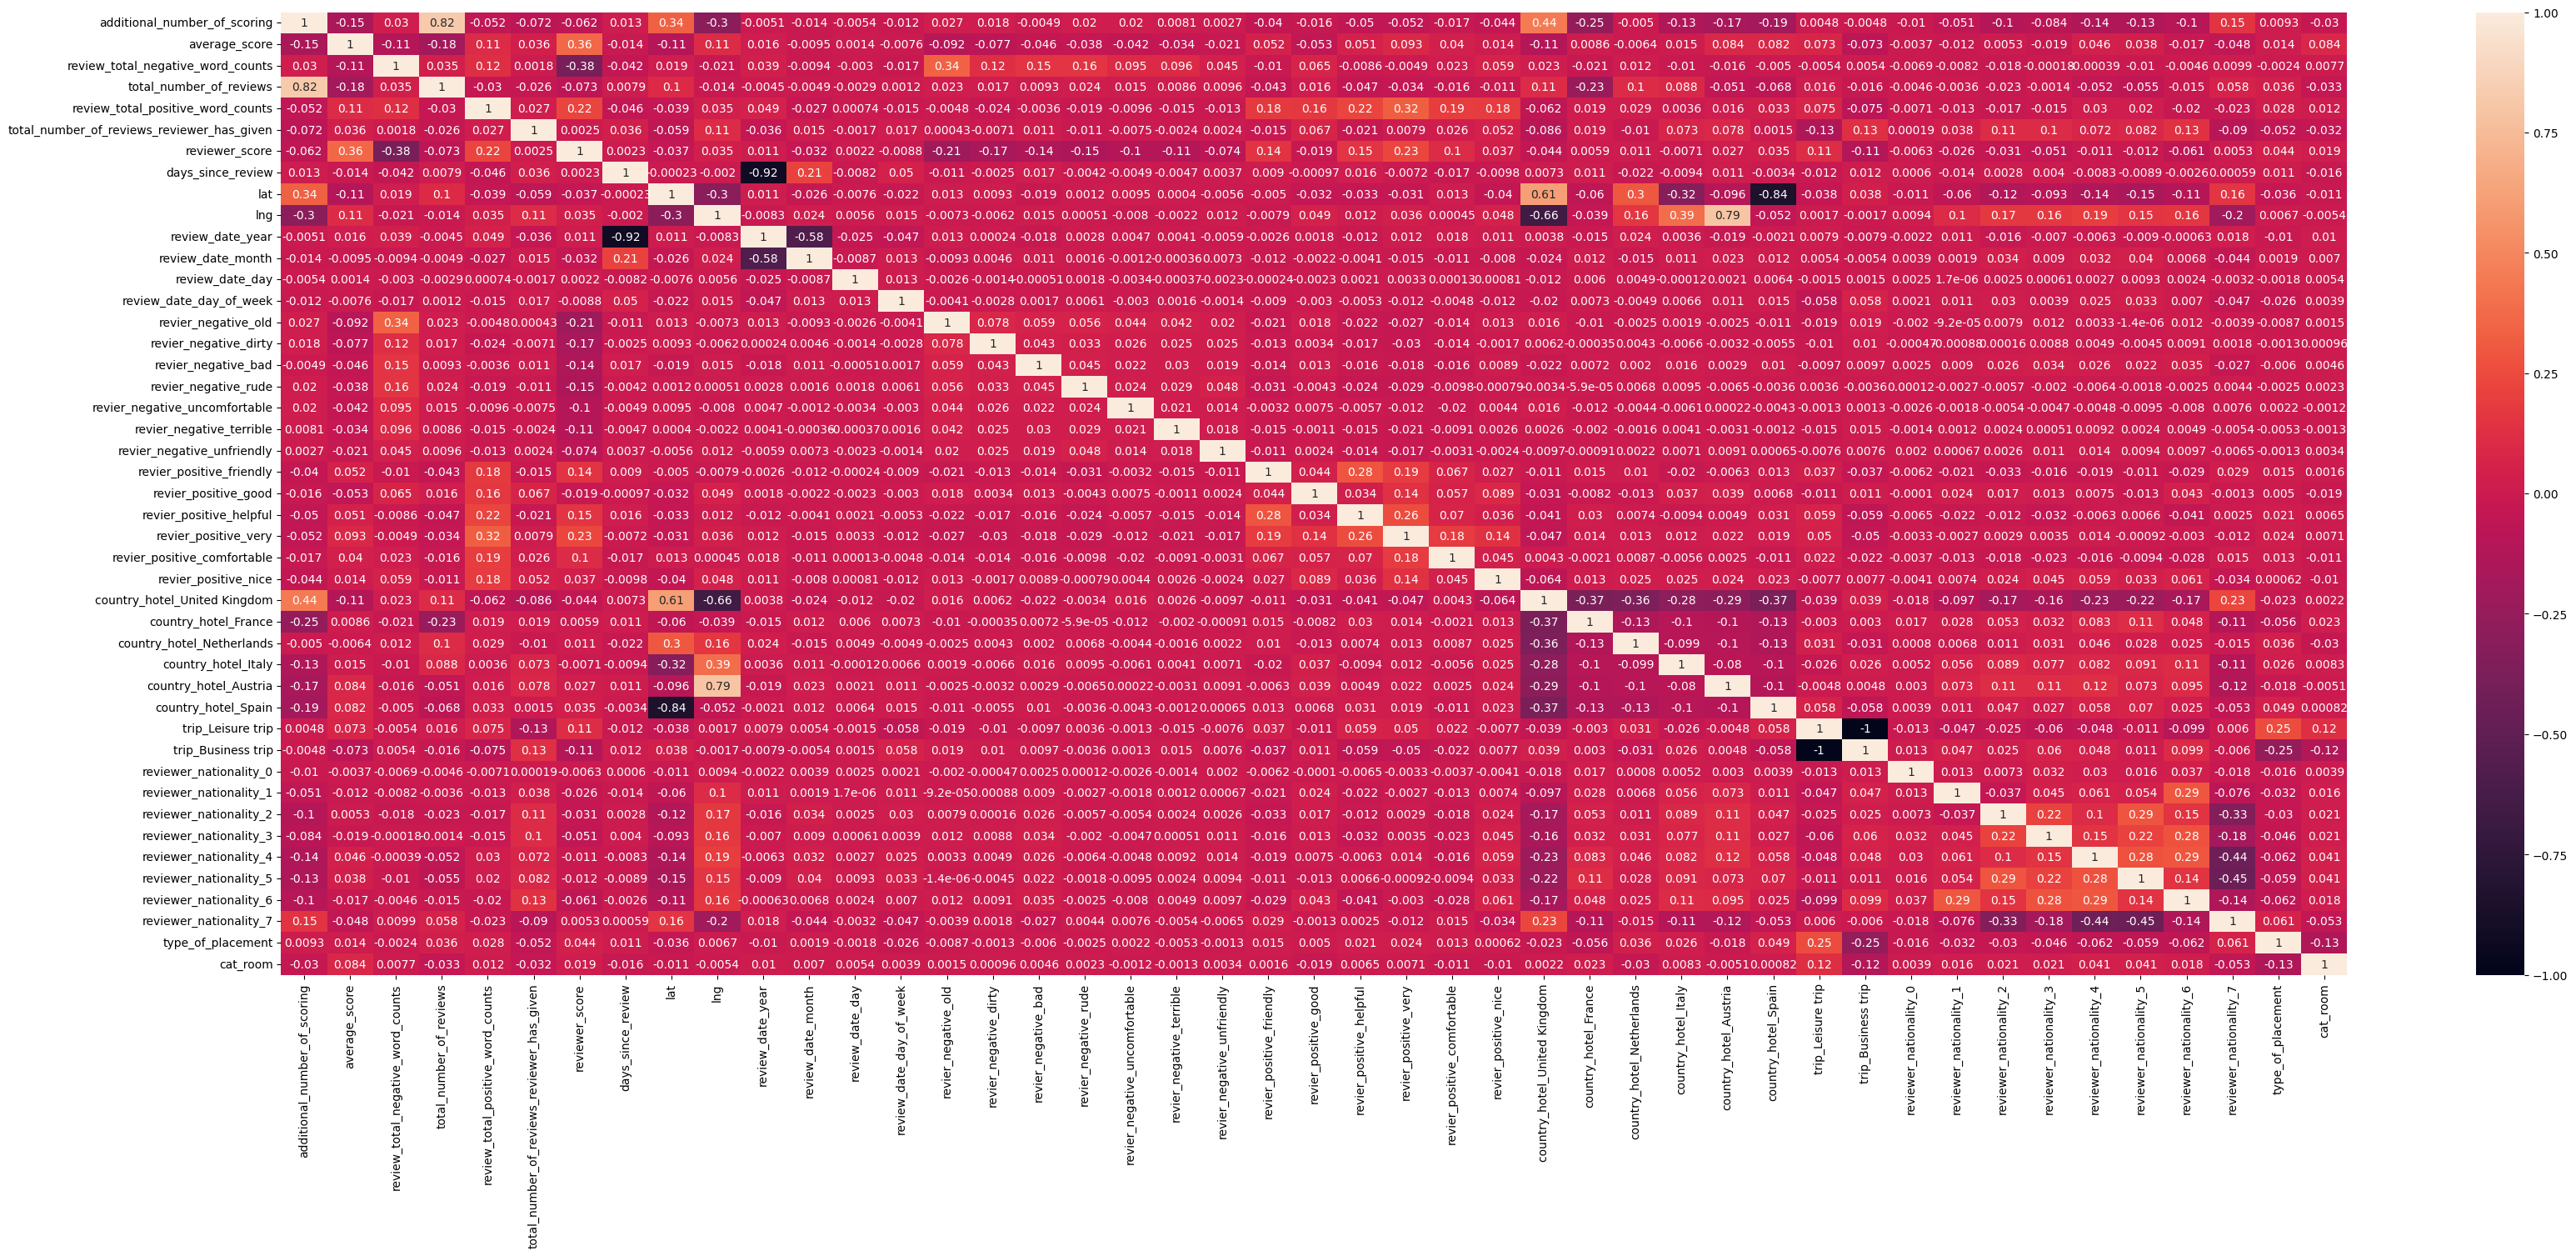

In [25]:
fig, ax = plt.subplots(figsize=(40, 15))  # Используем subplots для создания осей

# Построение тепловой карты
sns.heatmap(hotels.corr(numeric_only=True), ax=ax, annot=True)  # Используем ax вместо axes

In [26]:
hotels = hotels.drop(['hotel_address', 'review_date', 'hotel_name', 'reviewer_nationality', 'negative_review', 'positive_review', 'tags', 'country_hotel', 'type_of_placement', 'cat_room', 'trip'], axis=1)

In [27]:
hotels = hotels.drop(['days_since_review', 'lat', 'lng', 'trip_Business trip', 'additional_number_of_scoring'],  axis=1)

## Создание модели: результат метрики MAPE

In [28]:
X = hotels.drop(['reviewer_score'], axis = 1)  
y = hotels['reviewer_score']  
      
    # Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split  
      
    # Наборы данных с меткой "train" будут использоваться для обучения модели, "test" — для тестирования.  
    # Для тестирования мы будем использовать 25 % от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [29]:
# Импортируем необходимые библиотеки:  
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
      
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)

In [30]:
# Оцениваем метрику
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.13172484589838346


## Создание submission

In [ ]:
kaggle_test = pd.read_csv('data/hotels_test.csv')

fillna_values = {
    'lat': kaggle_test['lat'].mean(),
    'lng': kaggle_test['lng'].mean()
}
kaggle_test = kaggle_test.fillna(fillna_values)

kaggle_test['days_since_review'] = kaggle_test['days_since_review'].apply(fetch_days).astype(int)

kaggle_test['review_date_year'] = pd.to_datetime(kaggle_test['review_date']).dt.year

kaggle_test['review_date_month'] = pd.to_datetime(kaggle_test['review_date']).dt.month

kaggle_test['review_date_day'] = pd.to_datetime(kaggle_test['review_date']).dt.day

kaggle_test['review_date_day_of_week'] = pd.to_datetime(kaggle_test['review_date']).dt.day_of_week

kaggle_test['cat_room'] = kaggle_test['tags'].apply(get_count_people)

kaggle_test['type_of_placement'] = kaggle_test['tags'].apply(get_count_people)

kaggle_test['trip'] = kaggle_test['tags'].apply(type_trip)

kaggle_test['stayed_nights'] = kaggle_test['tags'].apply(stayed_nights)

kaggle_test['country_hotel'] = kaggle_test['hotel_address'].apply(get_country)

for i in need_bad_words:
    def get_bad_words(data):
        data = data.lower()
        if i in data: return 1
        return 0
    kaggle_test['revier_negative_'+i] =  kaggle_test['negative_review'].apply(get_bad_words)
    
for i in need_good_words:
    def get_good_words(data):
        data = data.lower()
        if i in data: return 1
        return 0
    kaggle_test['revier_positive_'+i] =  kaggle_test['positive_review'].apply(get_good_words)


In [37]:
oneHotEncoder = ['country_hotel', 'trip']
for i in oneHotEncoder:
    encoder = ce.OneHotEncoder(cols=[i], use_cat_names=True)
    type_bin = encoder.fit_transform(kaggle_test[i])
    kaggle_test = pd.concat([kaggle_test, type_bin], axis=1)

# бинарное кодирование
bin_encoder = ce.BinaryEncoder(cols=['reviewer_nationality'])
type_bin = bin_encoder.fit_transform(kaggle_test['reviewer_nationality'])
kaggle_test = pd.concat([kaggle_test, type_bin], axis=1)

# порядковое кодирование
ordinalEncoder = {'type_of_placement': {'is_none': 0, 'single': 1, 'double': 2, 
                'triple': 3, 'quadruple': 4}, 
                  
                'cat_room': {'standard': 1, 'superior': 2, 'deluxe': 3, 
                'family': 4, 'apartment': 5, 'junior suite': 6,
                'suite': 7, 'presidential suite': 8, 'royal suite': 8}}

for key, value in ordinalEncoder.items():
    ord_encoder = ce.OrdinalEncoder(mapping=[{
	'col': key,
	'mapping': value
    }])
    data_bin = ord_encoder.fit_transform(kaggle_test[[key]])
    kaggle_test = pd.concat([kaggle_test, data_bin], axis=1)

In [38]:
kaggle_test = kaggle_test.drop(['hotel_address', 'review_date', 'hotel_name', 'reviewer_nationality', 'negative_review', 'positive_review', 'tags', 'country_hotel', 'type_of_placement', 'cat_room', 'trip'], axis=1)

kaggle_test = kaggle_test.drop(['days_since_review', 'lat', 'lng', 'trip_Business trip', 'additional_number_of_scoring'],  axis=1)

In [ ]:
X_kaggle_test = kaggle_test[X_train.columns] 

kaggle_preds = regr.predict(X_kaggle_test)

In [ ]:
sample_submission = pd.read_csv('data/submission.csv')

submission = pd.DataFrame({
    'reviewer_score': kaggle_preds,
    'id': sample_submission['id']
})

# 4. Сохраняем результат
submission.to_csv('submission.csv', index=False)